In [108]:
import requests
import json
from datetime import datetime, timezone
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [5]:
BASE = "https://dashboard.elering.ee/api"
PARAMS = {
    "start": "2026-01-01T00:00:00.000Z",
    "end":   "2026-01-01T02:00:00.000Z"  # kun 2 timer — lille response
}

endpoints = {
    "system":               "/system",
}

for name, path in endpoints.items():
    try:
        r = requests.get(BASE + path, params=PARAMS)
        data = r.json()
        
        # Hent første datapunkt og print feltnavne
        if isinstance(data, dict) and "data" in data:
            items = data["data"]
            if isinstance(items, list) and len(items) > 0:
                first = items[0]
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Antal datapunkter: {len(items)}")
                print(f"   Felter: {list(first.keys()) if isinstance(first, dict) else type(first)}")
                print(f"   Første række: {first}")
            elif isinstance(items, dict):
                print(f"\n{'='*50}")
                print(f" {name} ({path})")
                print(f"   Felter: {list(items.keys())}")
                print(f"   Data: {items}")
        else:
            print(f"\n{'='*50}")
            print(f" {name} ({path})")
            print(f"   Rå svar: {str(data)[:200]}")
            
    except Exception as e:
        print(f"\n {name}: {e}")


 system (/system)
   Antal datapunkter: 25
   Felter: ['timestamp', 'production', 'consumption', 'losses', 'frequency', 'system_balance', 'ac_balance', 'production_renewable', 'solar_energy_production']
   Første række: {'timestamp': 1767225600, 'production': 264.18, 'consumption': 1047.28, 'losses': None, 'frequency': 49.96, 'system_balance': -783.1, 'ac_balance': -131.21, 'production_renewable': 76.68, 'solar_energy_production': 4.3}


<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2019'}, xlabel='Time', ylabel='Consumption'>

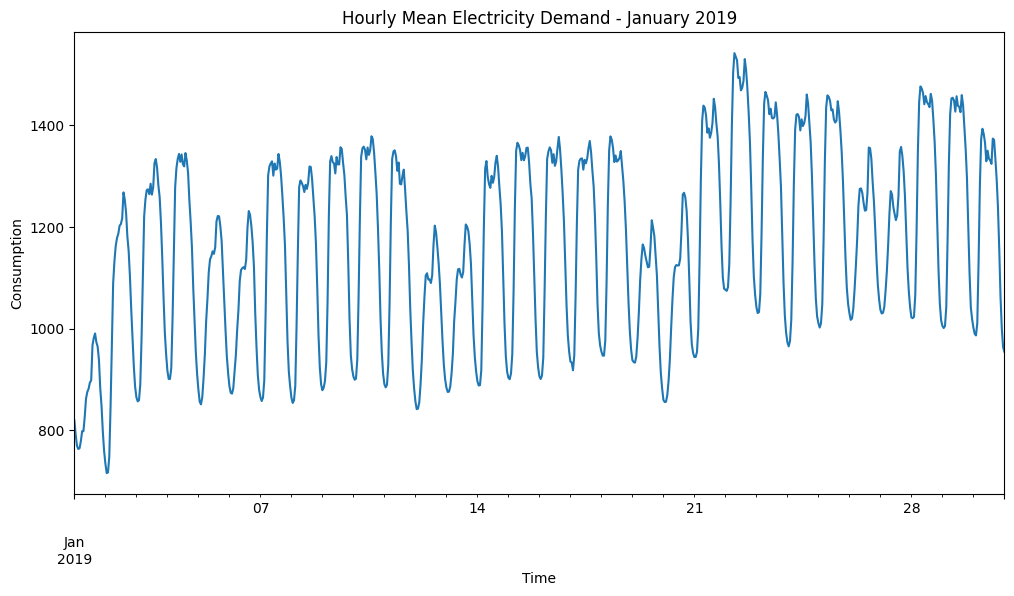

In [86]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response1 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2019-01-01T00:00:00.000Z",
        "end":   "2019-01-31T00:00:00.000Z"
    }
)

data1 = response1.json()

df1 = pd.DataFrame(data1["data"])
df1["timestamp"] = pd.to_datetime(df1["timestamp"], unit="s")
df1.set_index("timestamp", inplace=True)

demand_jan2019 = df1["consumption"].dropna()

# Cleaning 0-values around 11:40-11:45 on Jan 3, 2019
demand_jan2019.loc["2019-01-03 11:40:00"] = demand_jan2019.loc["2019-01-03 11:35:00"]
demand_jan2019.loc["2019-01-03 11:45:00"] = demand_jan2019.loc["2019-01-03 11:50:00"]

# Aggregate to hourly mean
demand_jan2019_hourly = demand_jan2019.resample("h").mean().dropna()

# Plot
demand_jan2019_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2019",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2020'}, xlabel='Time', ylabel='Consumption'>

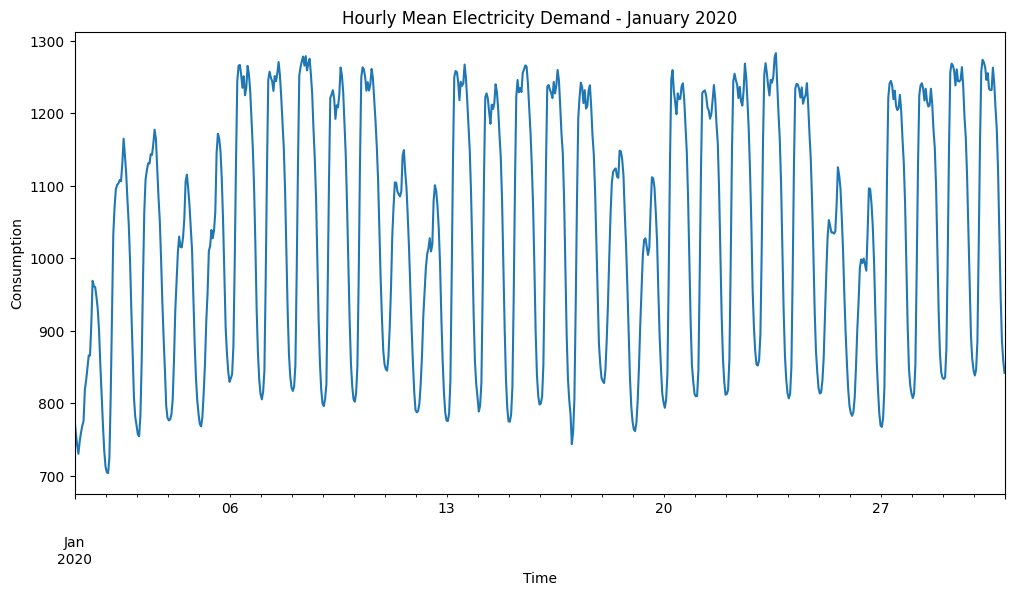

In [88]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response2 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2020-01-01T00:00:00.000Z",
        "end":   "2020-01-31T00:00:00.000Z"
    }
)

data2 = response2.json()

df2 = pd.DataFrame(data2["data"])
df2["timestamp"] = pd.to_datetime(df2["timestamp"], unit="s")
df2.set_index("timestamp", inplace=True)

demand_jan2020 = df2["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2020_hourly = demand_jan2020.resample("h").mean().dropna()

# Plot
demand_jan2020_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2020",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2021'}, xlabel='Time', ylabel='Consumption'>

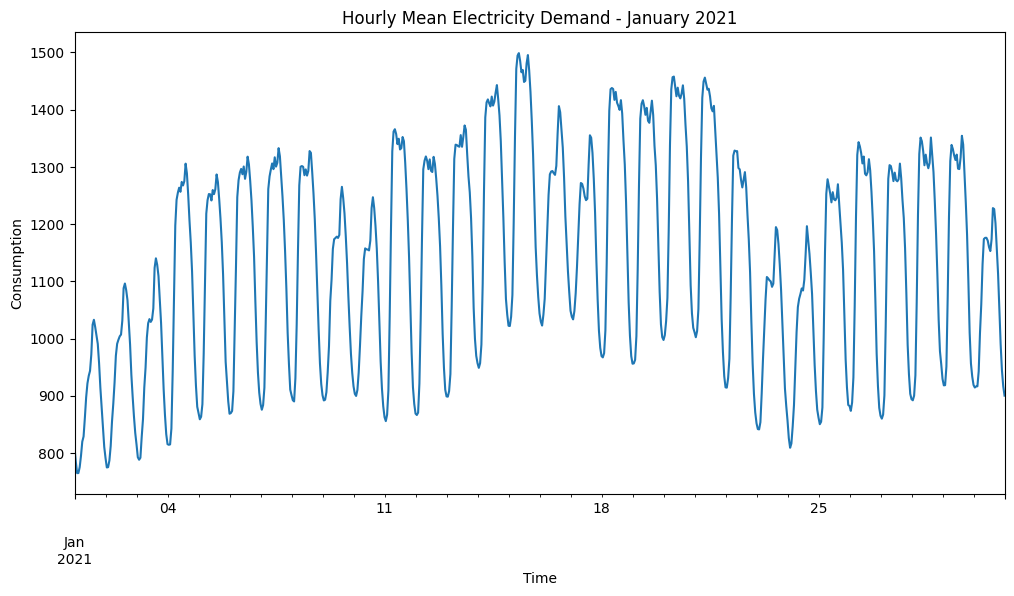

In [89]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response3 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2021-01-01T00:00:00.000Z",
        "end":   "2021-01-31T00:00:00.000Z"
    }
)

data3 = response3.json()

df3 = pd.DataFrame(data3["data"])
df3["timestamp"] = pd.to_datetime(df3["timestamp"], unit="s")
df3.set_index("timestamp", inplace=True)

demand_jan2021 = df3["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2021_hourly = demand_jan2021.resample("h").mean().dropna()

# Plot
demand_jan2021_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2021",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2022'}, xlabel='Time', ylabel='Consumption'>

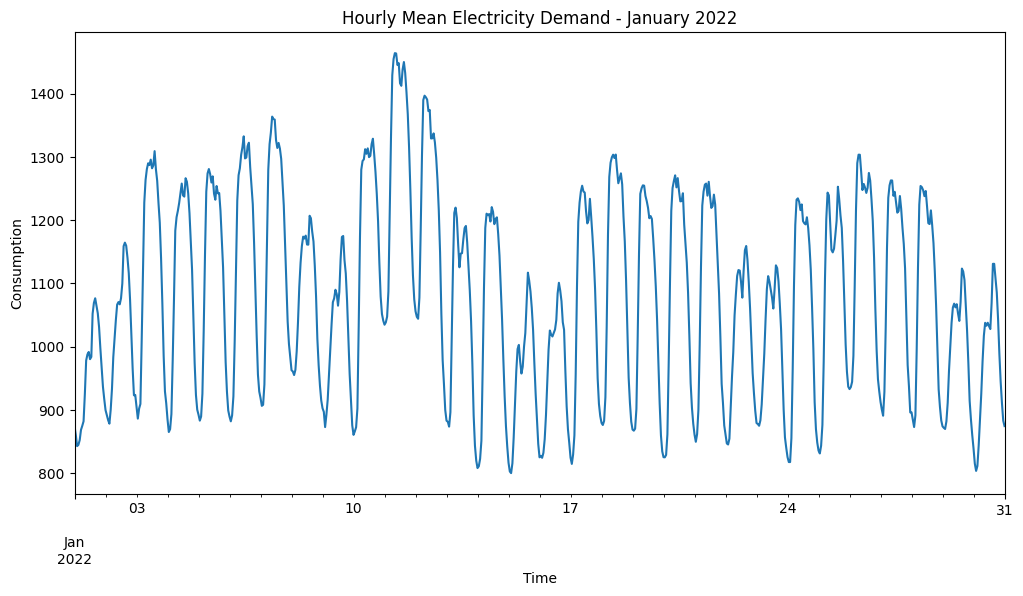

In [90]:
# Lige før EstLink 2 nedbrud 25. dec 2024
response4 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2022-01-01T00:00:00.000Z",
        "end":   "2022-01-31T00:00:00.000Z"
    }
)

data4 = response4.json()

df4 = pd.DataFrame(data4["data"])
df4["timestamp"] = pd.to_datetime(df4["timestamp"], unit="s")
df4.set_index("timestamp", inplace=True)

demand_jan2022 = df4["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2022_hourly = demand_jan2022.resample("h").mean().dropna()

# Plot
demand_jan2022_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2022",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2023'}, xlabel='Time', ylabel='Consumption'>

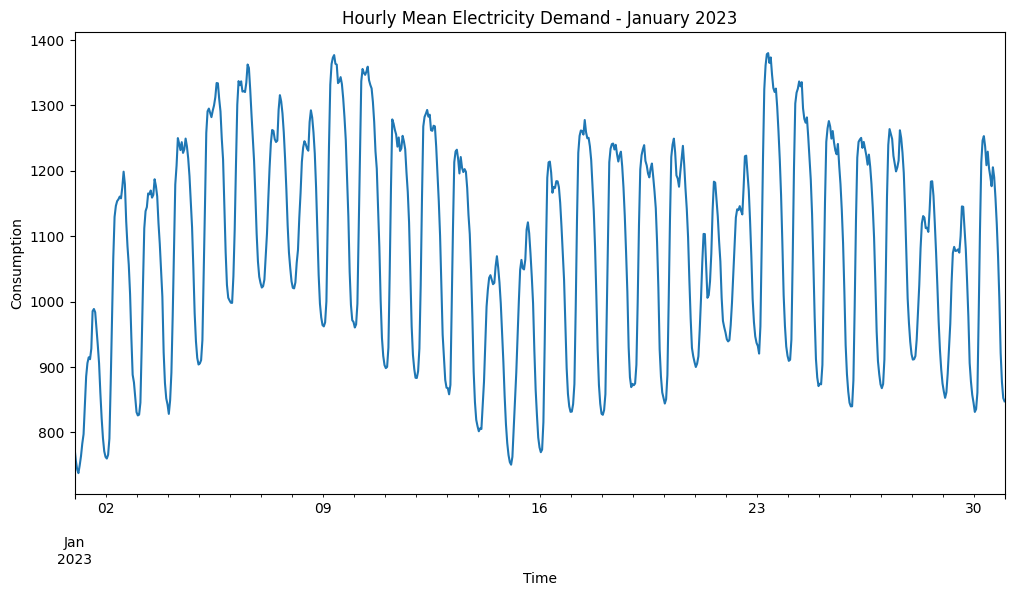

In [92]:
response5 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2023-01-01T00:00:00.000Z",
        "end":   "2023-01-31T00:00:00.000Z"
    }
)

data5 = response5.json()

df5 = pd.DataFrame(data5["data"])
df5["timestamp"] = pd.to_datetime(df5["timestamp"], unit="s")
df5.set_index("timestamp", inplace=True)

demand_jan2023 = df5["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2023_hourly = demand_jan2023.resample("h").mean().dropna()

# Plot
demand_jan2023_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2023",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2024'}, xlabel='Time', ylabel='Consumption'>

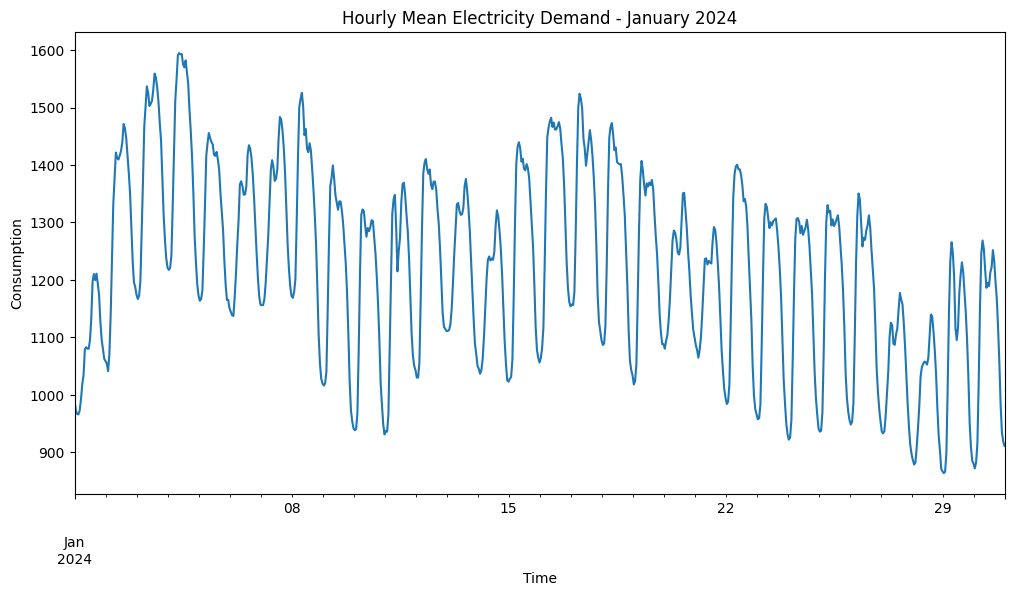

In [93]:
response6 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2024-01-01T00:00:00.000Z",
        "end":   "2024-01-31T00:00:00.000Z"
    }
)

data6 = response6.json()

df6 = pd.DataFrame(data6["data"])
df6["timestamp"] = pd.to_datetime(df6["timestamp"], unit="s")
df6.set_index("timestamp", inplace=True)

demand_jan2024 = df6["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2024_hourly = demand_jan2024.resample("h").mean().dropna()

# Plot
demand_jan2024_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2024",
    xlabel="Time",
    ylabel="Consumption"
)

<AxesSubplot: title={'center': 'Hourly Mean Electricity Demand - January 2025'}, xlabel='Time', ylabel='Consumption'>

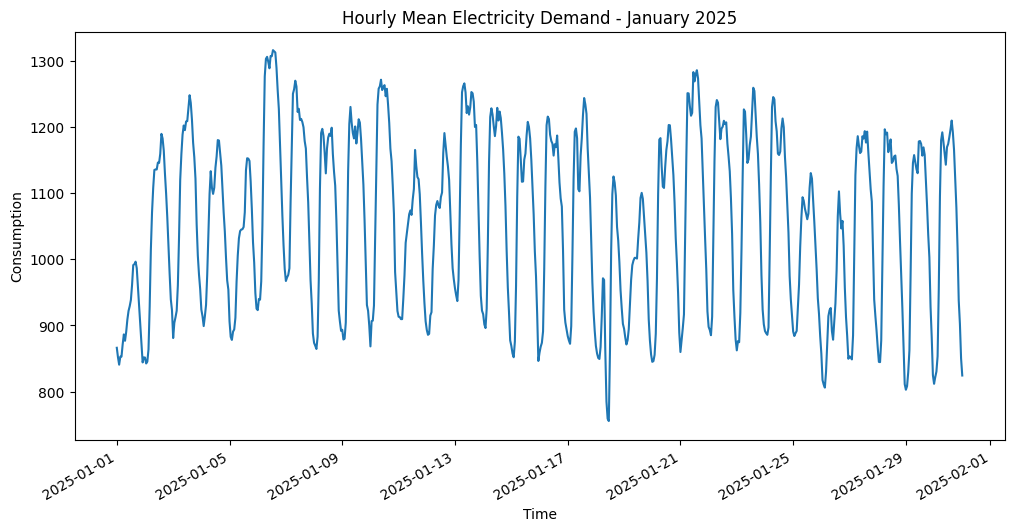

In [94]:
response7 = requests.get(
    "https://dashboard.elering.ee/api/system",
    params={
        "start": "2025-01-01T00:00:00.000Z",
        "end":   "2025-01-31T00:00:00.000Z"
    }
)

data7 = response7.json()

df7 = pd.DataFrame(data7["data"])
df7["timestamp"] = pd.to_datetime(df7["timestamp"], unit="s")
df7.set_index("timestamp", inplace=True)

demand_jan2025 = df7["consumption"].dropna()

# Aggregate to hourly mean
demand_jan2025_hourly = demand_jan2025.resample("h").mean().dropna()

# Plot
demand_jan2025_hourly.plot(
    figsize=(12, 6),
    title="Hourly Mean Electricity Demand - January 2025",
    xlabel="Time",
    ylabel="Consumption"
)

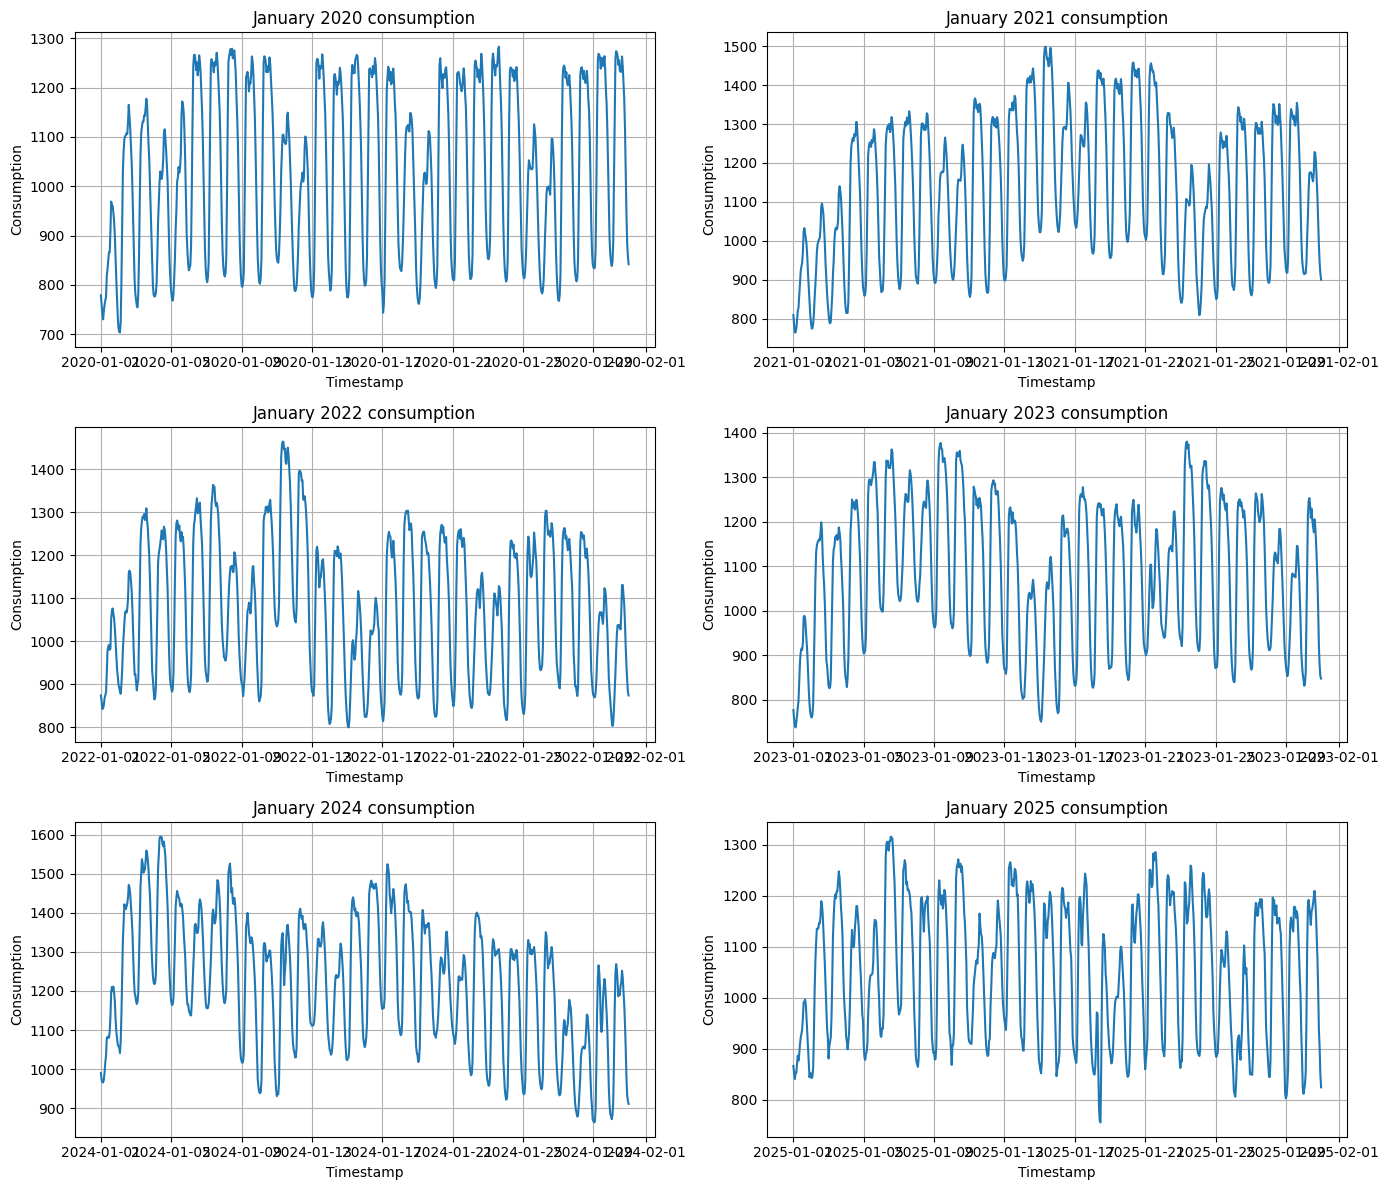

In [96]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False, sharey=False)

years = [2020, 2021, 2022, 2023, 2024, 2025]
series_list = [
    demand_jan2020_hourly,
    demand_jan2021_hourly,
    demand_jan2022_hourly,
    demand_jan2023_hourly,
    demand_jan2024_hourly,
    demand_jan2025_hourly,
]

for ax, year, series in zip(axes.flatten(), years, series_list):
    ax.plot(series.index, series.values)
    ax.set_title(f"January {year} consumption")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Consumption")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [105]:
def plot_acf_pacf(series, title, lags=168):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF: {title}")
    axes[0].grid(True)

    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: {title}")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

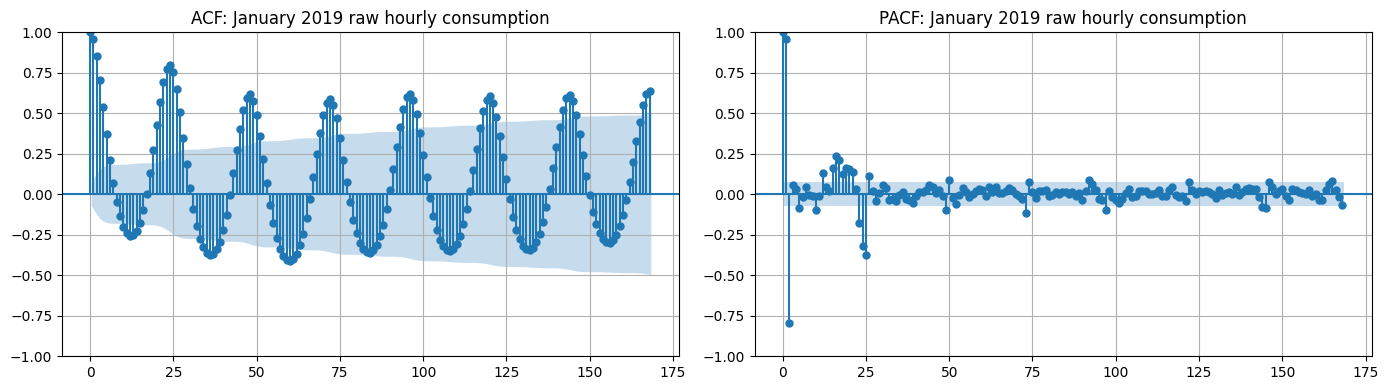

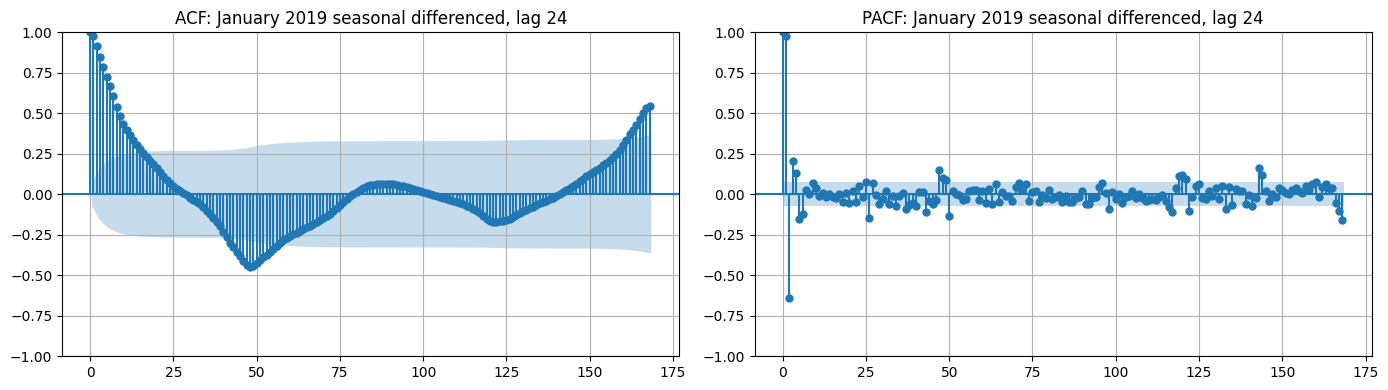

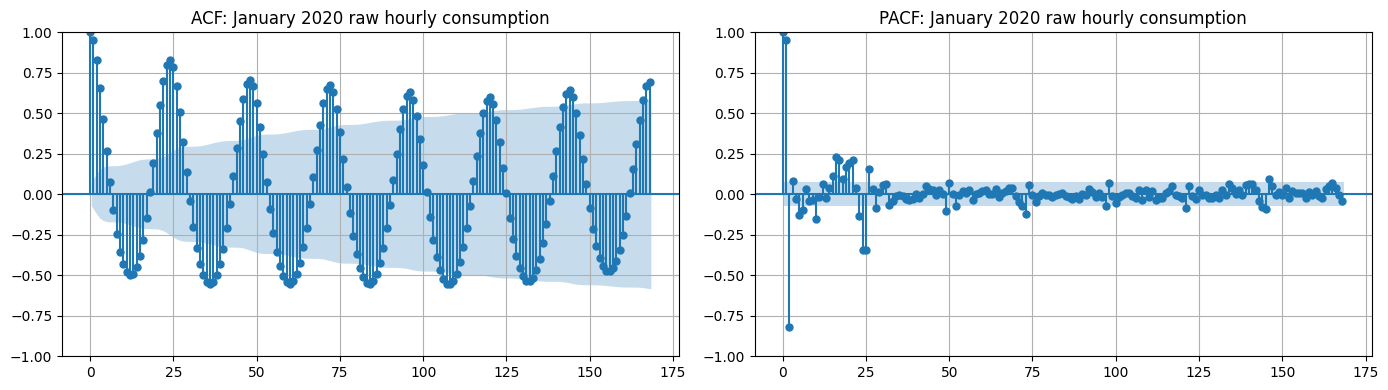

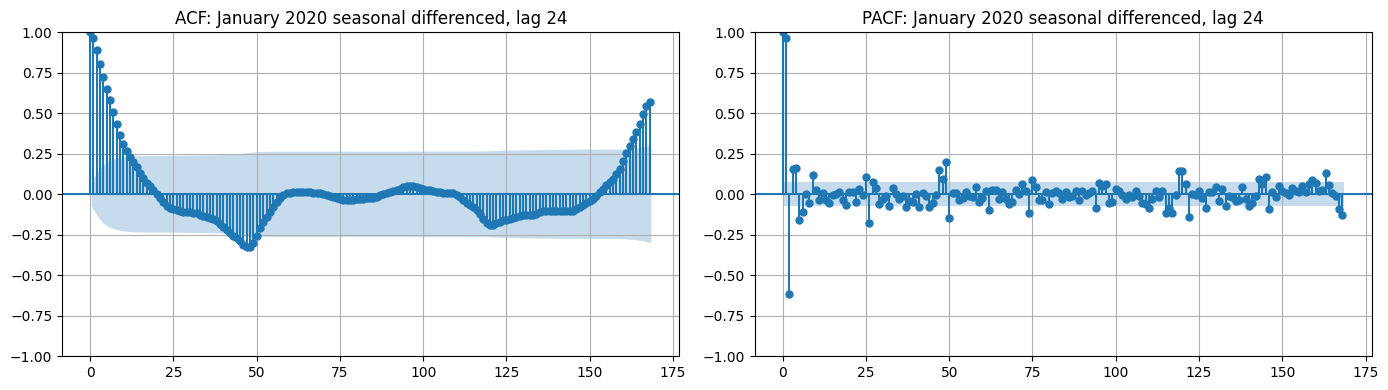

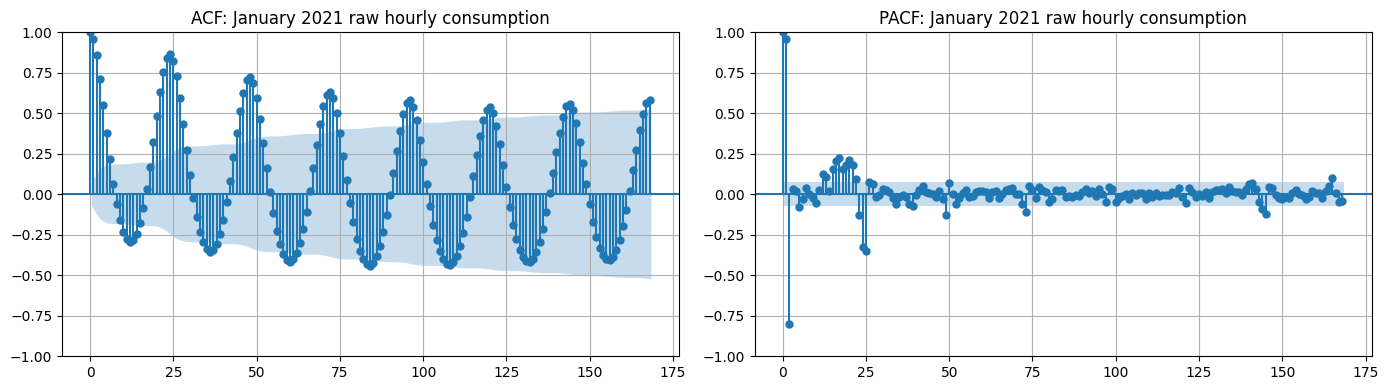

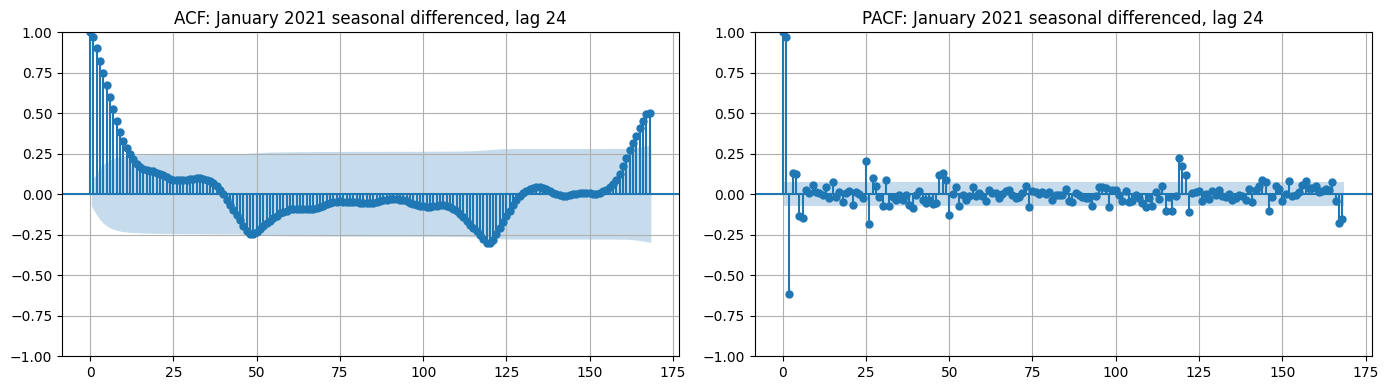

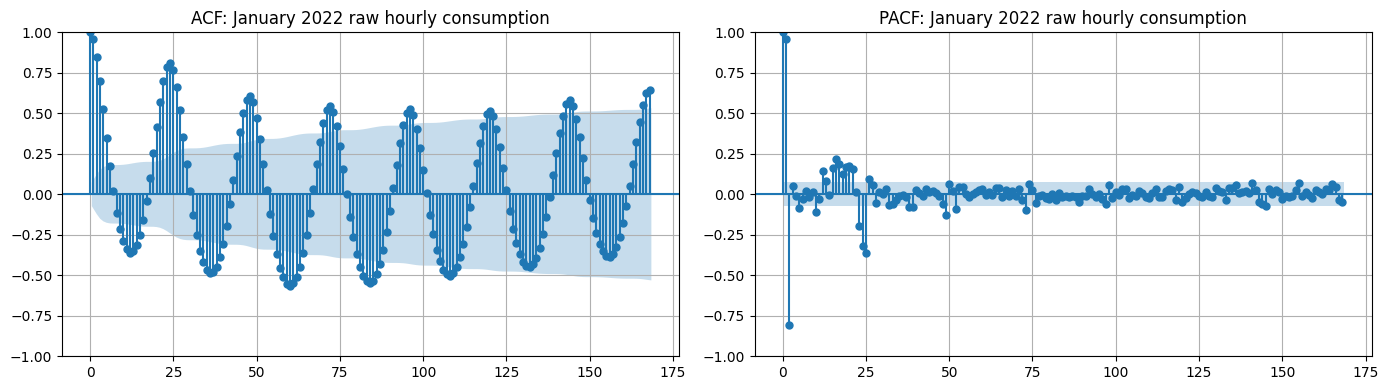

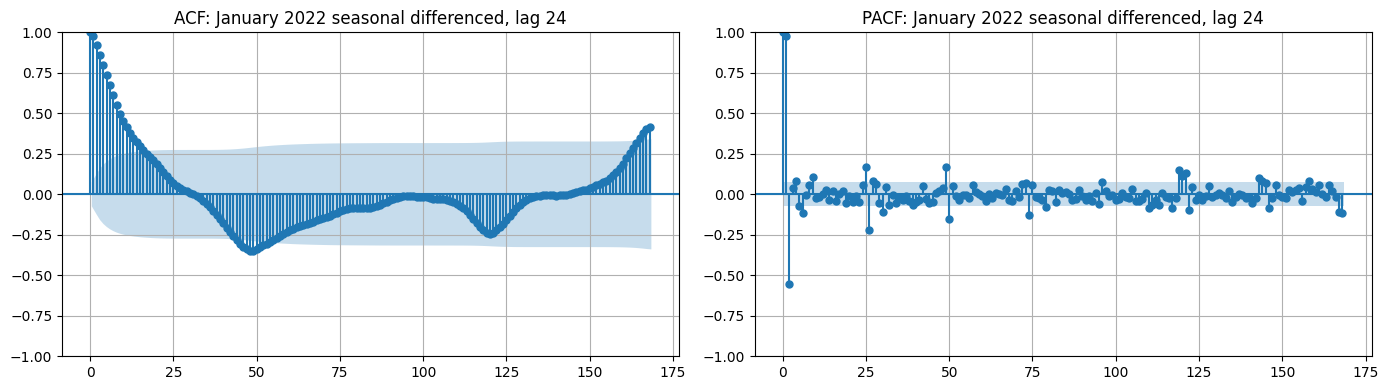

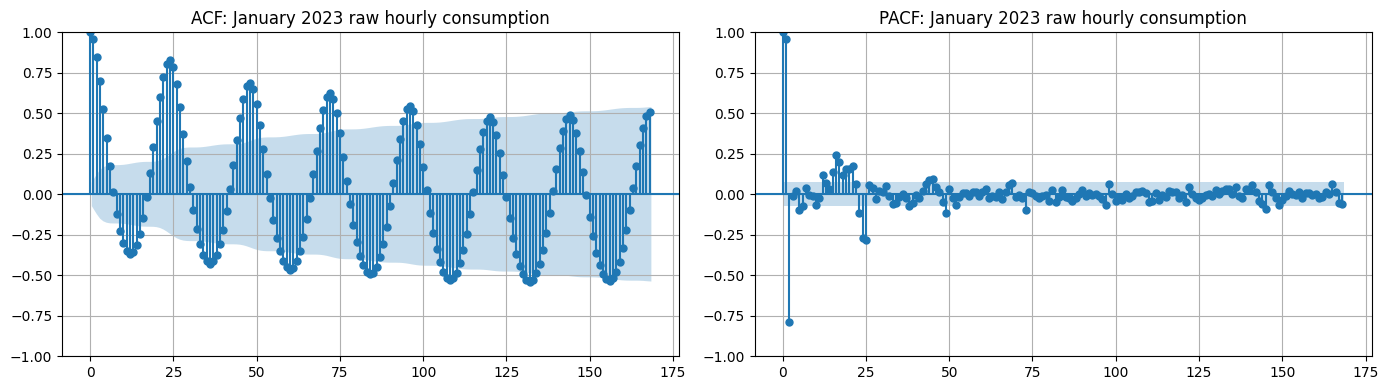

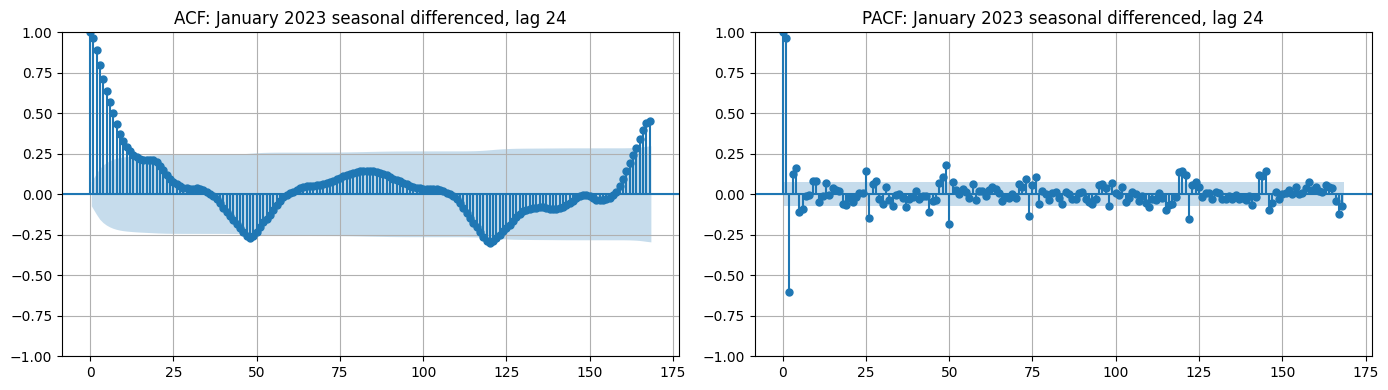

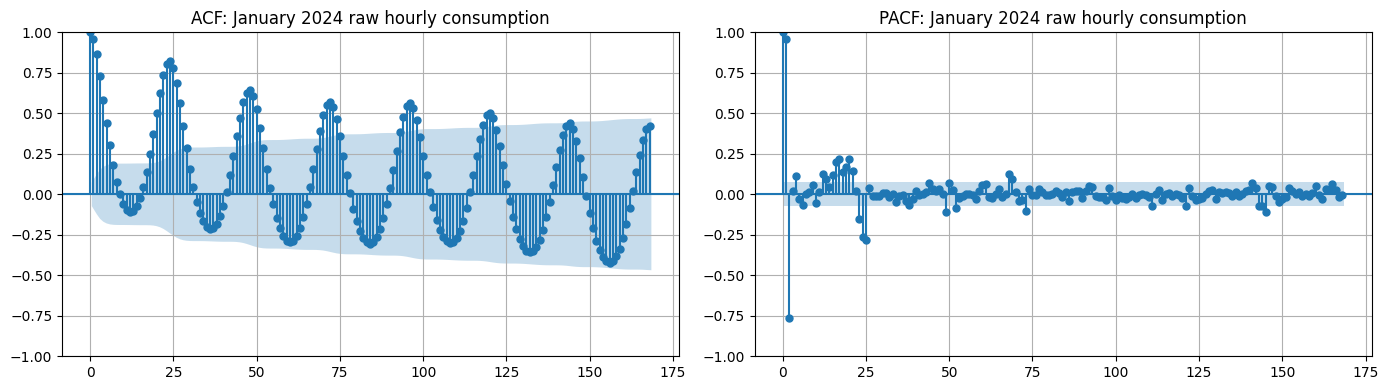

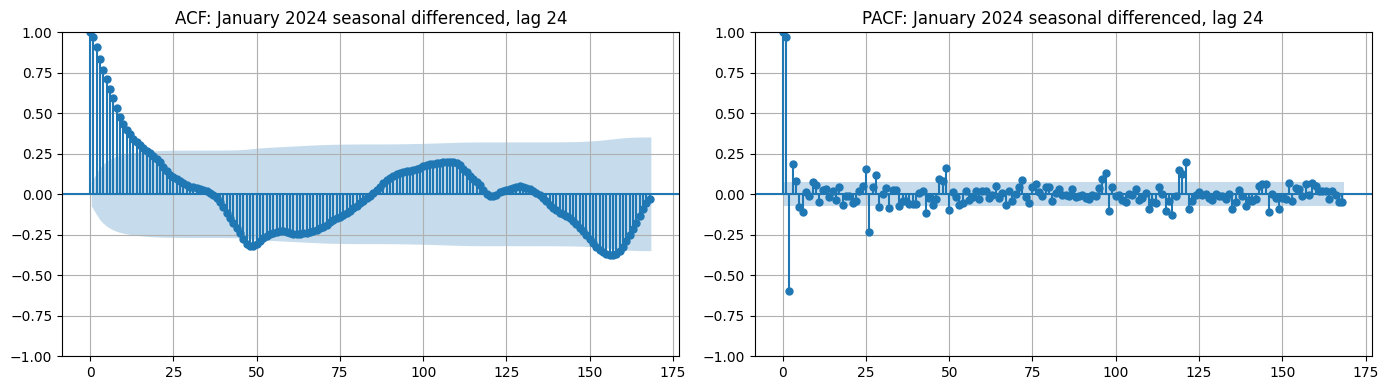

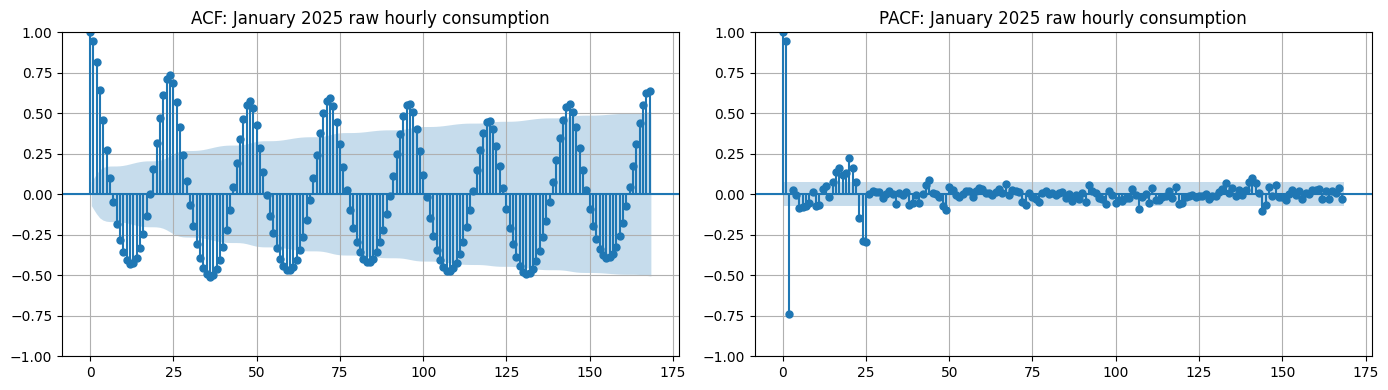

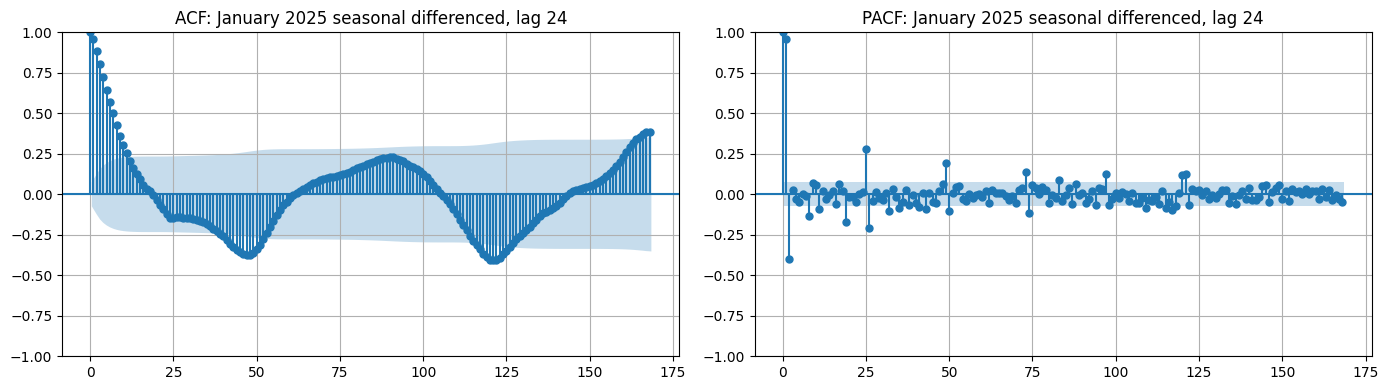

In [107]:
demand_series = {
    2019: demand_jan2019_hourly,
    2020: demand_jan2020_hourly,
    2021: demand_jan2021_hourly,
    2022: demand_jan2022_hourly,
    2023: demand_jan2023_hourly,
    2024: demand_jan2024_hourly,
    2025: demand_jan2025_hourly,
}

for year, y in demand_series.items():
    plot_acf_pacf(y, f"January {year} raw hourly consumption", lags=168)

    y_sdiff = y.diff(24)
    plot_acf_pacf(y_sdiff, f"January {year} seasonal differenced, lag 24", lags=168)

In [123]:
candidate_models = [
    ((2, 0, 2), (0, 1, 1, 24)),
    ((3, 0, 1), (0, 1, 1, 24)),
    ((2, 0, 2), (1, 1, 1, 24)),
    ((3, 0, 1), (1, 1, 1, 24)),
    ((3, 0, 2), (0, 1, 1, 24)),
    ((3, 0, 2), (1, 1, 1, 24)),
]

results = []

y = demand_jan2024_hourly.dropna()

for order, seasonal_order in candidate_models:
    try:
        model = SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        lb = acorr_ljungbox(fit.resid.dropna(), lags=[24], return_df=True)

        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "Ljung-Box p-value lag 24": lb["lb_pvalue"].iloc[0]
        })

    except Exception as e:
        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": None,
            "BIC": None,
            "Ljung-Box p-value lag 24": None,
            "error": str(e)
        })

model_comparison = pd.DataFrame(results)
display(model_comparison.sort_values("AIC"))

/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24
5,"(3, 0, 2)","(1, 1, 1, 24)",5422.704078,5458.762300,2.674344e-25
2,"(2, 0, 2)","(1, 1, 1, 24)",5428.598092,5460.149036,1.371078e-40
3,"(3, 0, 1)","(1, 1, 1, 24)",5441.121644,5472.672588,3.505418e-25
4,"(3, 0, 2)","(0, 1, 1, 24)",5446.716606,5478.267550,2.227588e-21
0,"(2, 0, 2)","(0, 1, 1, 24)",5451.616344,5478.660010,5.750753e-36
1,"(3, 0, 1)","(0, 1, 1, 24)",5476.088070,5503.140685,1.664130e-20


In [124]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
import numpy as np
import warnings
from IPython.display import display

# -----------------------------
# 1. Collect all yearly demand series
# -----------------------------
demand_series = {
    2019: demand_jan2019_hourly,
    2020: demand_jan2020_hourly,
    2021: demand_jan2021_hourly,
    2022: demand_jan2022_hourly,
    2023: demand_jan2023_hourly,
    2024: demand_jan2024_hourly,
    2025: demand_jan2025_hourly,
}

# -----------------------------
# 2. Define candidate SARIMA models
# -----------------------------
candidate_models = [
    ((2, 0, 2), (0, 1, 1, 24)),
    ((2, 0, 2), (1, 1, 1, 24)),
    ((3, 0, 1), (1, 1, 1, 24)),
    ((3, 0, 2), (0, 1, 1, 24)),
    ((3, 0, 2), (1, 1, 1, 24)),
]

# Choose ranking metric
rank_metric = "AIC"   # use "BIC" if you prefer simpler models

# -----------------------------
# 3. Fit models year by year
# -----------------------------
all_results = []

for year, y in demand_series.items():

    y = y.dropna()

    yearly_results = []

    for model_id, (order, seasonal_order) in enumerate(candidate_models):

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fit = model.fit(disp=False)

            lb = acorr_ljungbox(
                fit.resid.dropna(),
                lags=[24],
                return_df=True
            )

            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fit.aic,
                "BIC": fit.bic,
                "Ljung-Box p-value lag 24": lb.loc[24, "lb_pvalue"],
                "converged": fit.mle_retvals.get("converged", None)
            })

        except Exception as e:
            yearly_results.append({
                "year": year,
                "model_id": model_id,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": np.nan,
                "BIC": np.nan,
                "Ljung-Box p-value lag 24": np.nan,
                "converged": False,
                "error": str(e)
            })

    yearly_table = pd.DataFrame(yearly_results)

    # Sort by chosen ranking metric
    yearly_table = yearly_table.sort_values(rank_metric, ascending=True).reset_index(drop=True)

    # Score: best = 5, second = 4, ..., fifth = 1
    yearly_table["score"] = 0
    yearly_table.loc[:4, "score"] = list(range(5, 0, -1))

    print(f"\nModel comparison for January {year}, ranked by {rank_metric}")
    display(yearly_table)

    all_results.append(yearly_table)

# -----------------------------
# 4. Combine all yearly results
# -----------------------------
all_results_df = pd.concat(all_results, ignore_index=True)

# -----------------------------
# 5. Total score across all years
# -----------------------------
score_summary = (
    all_results_df
    .groupby(["order", "seasonal_order"], as_index=False)
    .agg(
        total_score=("score", "sum"),
        mean_score=("score", "mean"),
        mean_AIC=("AIC", "mean"),
        mean_BIC=("BIC", "mean"),
        median_AIC=("AIC", "median"),
        median_BIC=("BIC", "median"),
        first_places=("score", lambda x: (x == 5).sum()),
        years_tested=("score", "count")
    )
    .sort_values(
        ["total_score", "first_places", "mean_AIC"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

print("\nOverall model score across all years")
display(score_summary)

# -----------------------------
# 6. Extract the overall best model
# -----------------------------
best_overall_model = score_summary.iloc[0]

print("Best overall model:")
print(f"order = {best_overall_model['order']}")
print(f"seasonal_order = {best_overall_model['seasonal_order']}")
print(f"total_score = {best_overall_model['total_score']}")
print(f"first_places = {best_overall_model['first_places']}")
print(f"mean_AIC = {best_overall_model['mean_AIC']:.2f}")
print(f"mean_BIC = {best_overall_model['mean_BIC']:.2f}")


Model comparison for January 2019, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2019,1,"(2, 0, 2)","(1, 1, 1, 24)",5440.267258,5471.818202,4.855649e-42,True,5
1,2019,3,"(3, 0, 2)","(0, 1, 1, 24)",5485.663540,5517.214484,1.119978e-20,True,4
2,2019,4,"(3, 0, 2)","(1, 1, 1, 24)",5487.813201,5523.871423,4.178833e-20,True,3
3,2019,0,"(2, 0, 2)","(0, 1, 1, 24)",5493.631557,5520.675224,1.702116e-30,True,2
4,2019,2,"(3, 0, 1)","(1, 1, 1, 24)",5519.014211,5550.565155,2.692059e-14,False,1



Model comparison for January 2020, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2020,4,"(3, 0, 2)","(1, 1, 1, 24)",5435.537073,5471.595294,1.006745e-35,True,5
1,2020,1,"(2, 0, 2)","(1, 1, 1, 24)",5435.958558,5467.509502,1.544610e-68,True,4
2,2020,2,"(3, 0, 1)","(1, 1, 1, 24)",5462.229272,5493.780216,2.475490e-21,True,3
3,2020,3,"(3, 0, 2)","(0, 1, 1, 24)",5478.129839,5509.680783,4.401785e-24,True,2
4,2020,0,"(2, 0, 2)","(0, 1, 1, 24)",5481.046193,5508.089859,2.084166e-54,True,1



Model comparison for January 2021, ranked by AIC


...


Model comparison for January 2025, ranked by AIC


,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,score
0,2025,2,"(3, 0, 1)","(1, 1, 1, 24)",5906.360497,5937.900985,4.784008e-16,False,5
1,2025,0,"(2, 0, 2)","(0, 1, 1, 24)",5909.391416,5936.426120,2.271377e-49,True,4
2,2025,1,"(2, 0, 2)","(1, 1, 1, 24)",5910.819015,5942.359504,6.405355e-48,True,3
3,2025,4,"(3, 0, 2)","(1, 1, 1, 24)",5957.921476,5993.967749,1.339614e-15,False,2
4,2025,3,"(3, 0, 2)","(0, 1, 1, 24)",5958.051224,5989.591713,1.682543e-15,False,1



Overall model score across all years


,order,seasonal_order,total_score,mean_score,mean_AIC,mean_BIC,median_AIC,median_BIC,first_places,years_tested
0,"(2, 0, 2)","(1, 1, 1, 24)",30,4.285714,5497.983571,5529.533022,5435.958558,5467.509502,3,7
1,"(3, 0, 2)","(1, 1, 1, 24)",28,4.000000,5510.083184,5546.139699,5435.537073,5471.595294,3,7
2,"(3, 0, 1)","(1, 1, 1, 24)",21,3.000000,5520.473510,5552.022961,5462.229272,5493.780216,1,7
3,"(3, 0, 2)","(0, 1, 1, 24)",14,2.000000,5536.757463,5568.306914,5478.129839,5509.680783,0,7
4,"(2, 0, 2)","(0, 1, 1, 24)",12,1.714286,5532.815137,5559.857523,5481.046193,5508.089859,0,7


Best overall model:
order = (2, 0, 2)
seasonal_order = (1, 1, 1, 24)
total_score = 30
first_places = 3
mean_AIC = 5497.98
mean_BIC = 5529.53


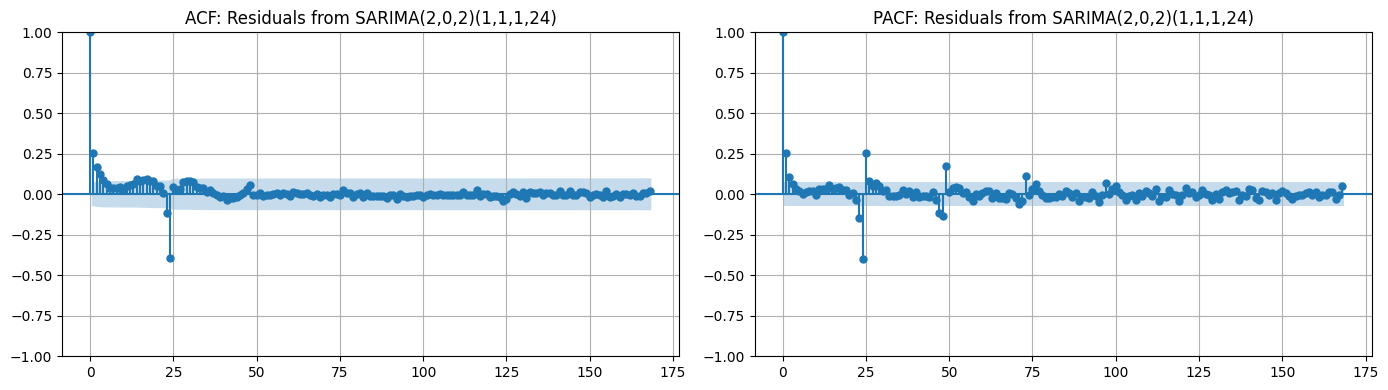

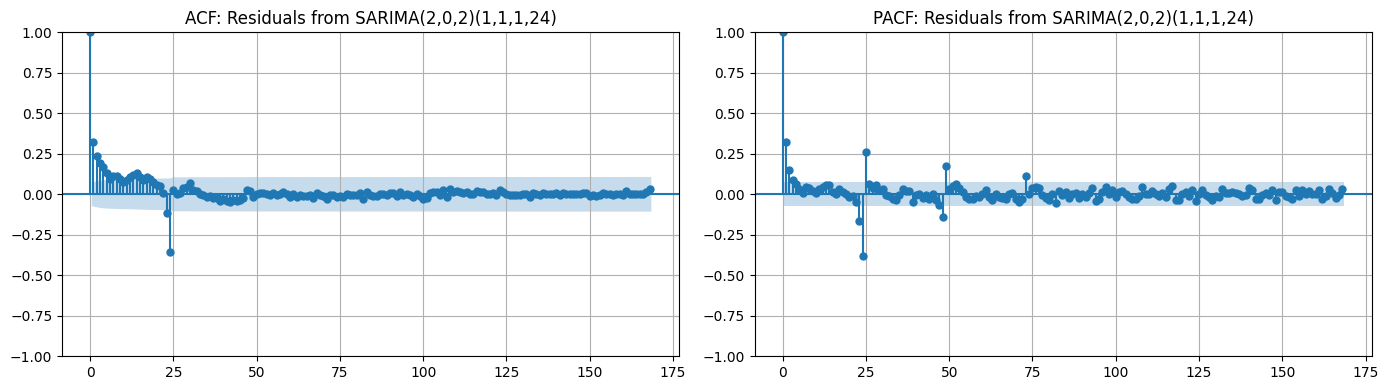

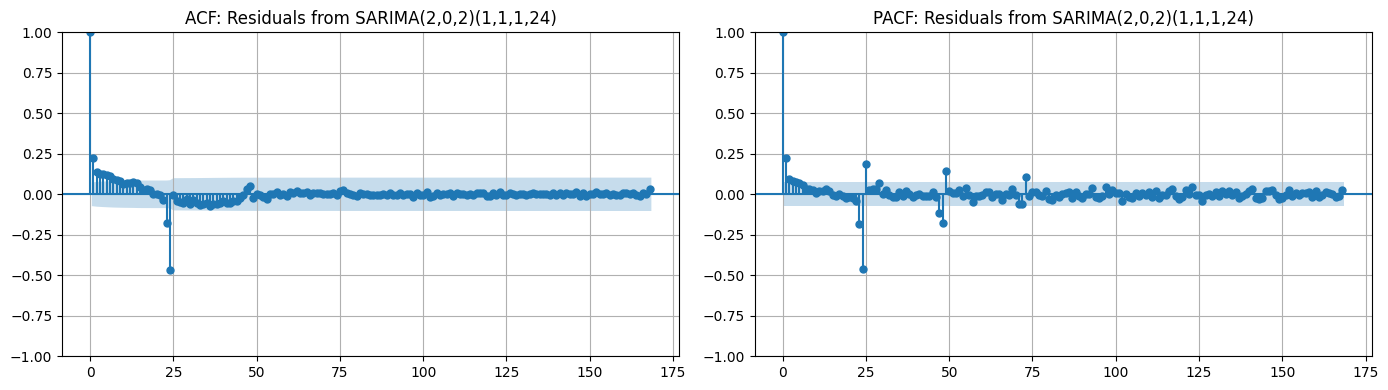

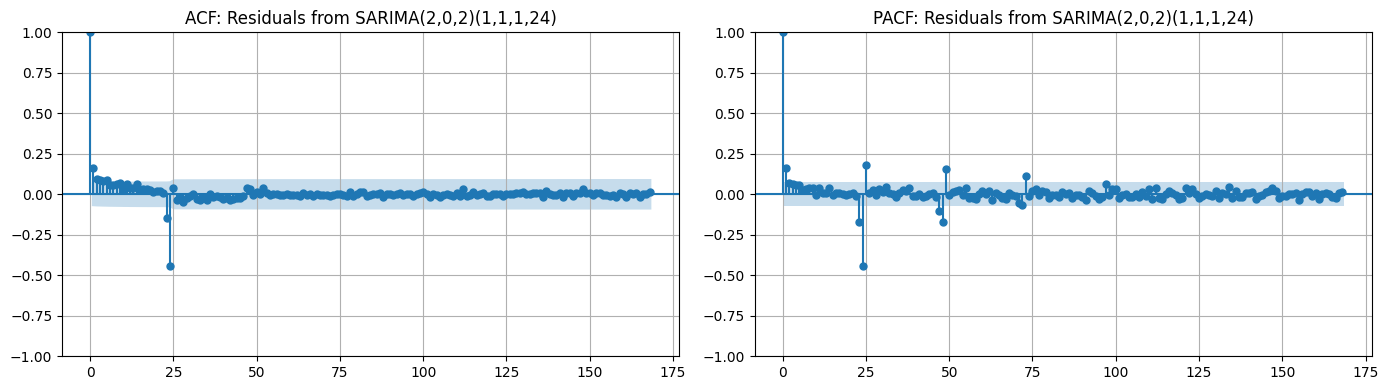

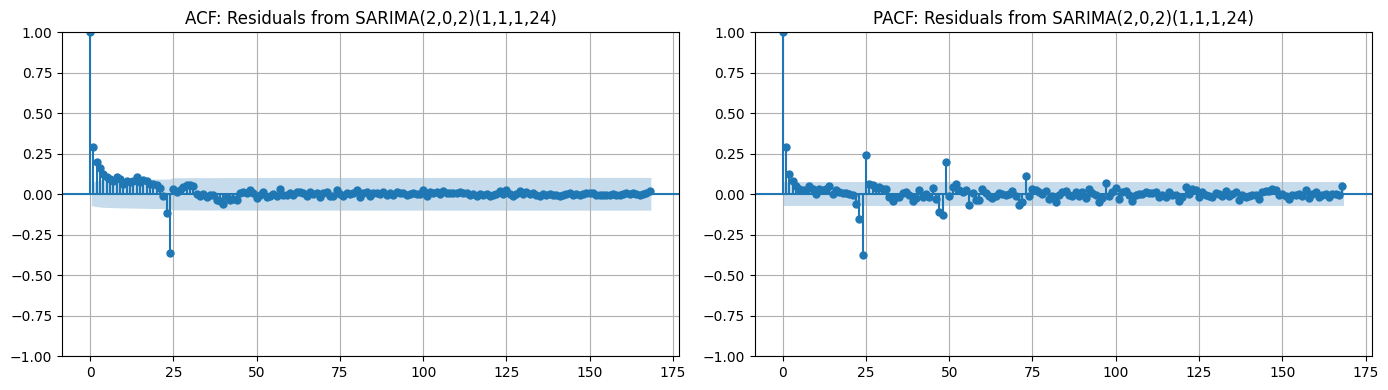

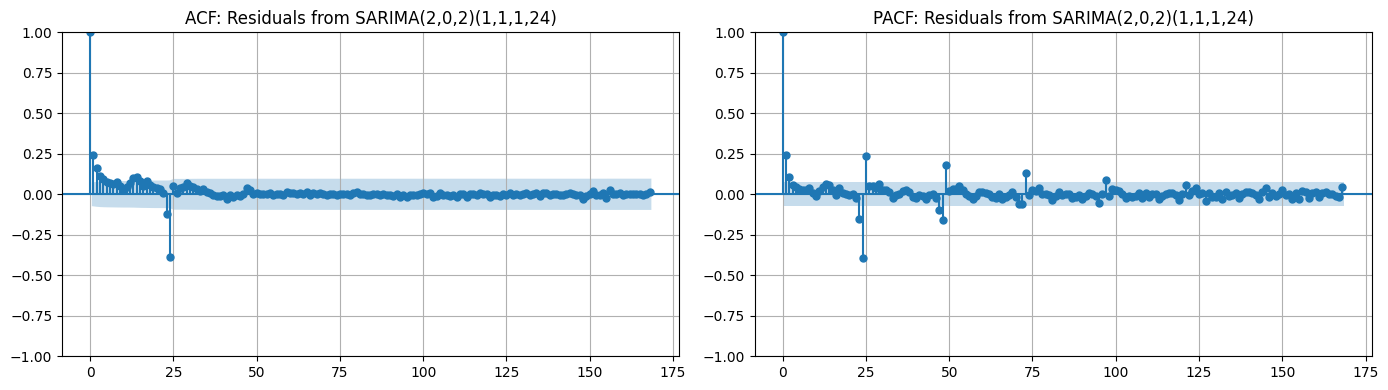

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


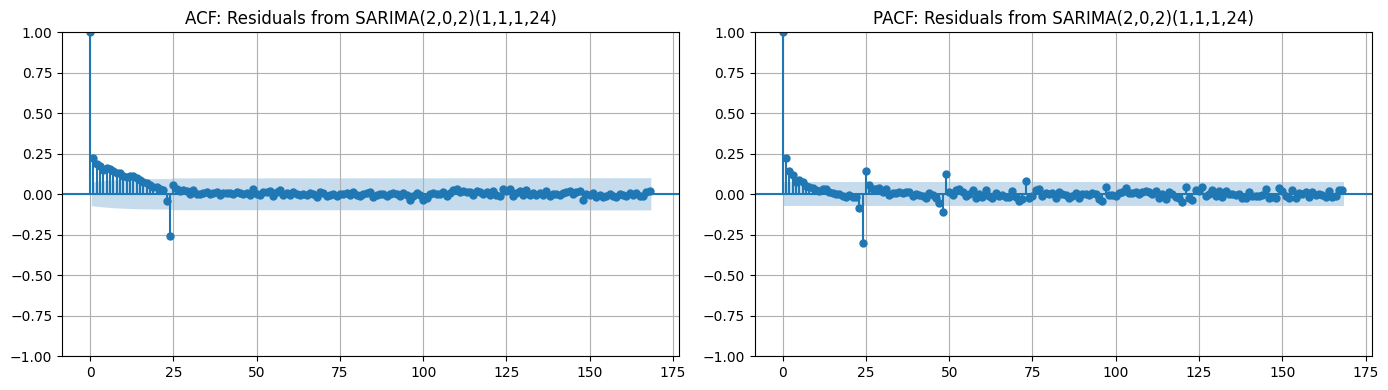

In [128]:
for year, y in demand_series.items():
    best_model = SARIMAX(
        y,
        order=(2, 0, 2),
        seasonal_order=(1, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    best_fit = best_model.fit(disp=False)

    resid = best_fit.resid.dropna()

    plot_acf_pacf(
        resid,
        "Residuals from SARIMA(2,0,2)(1,1,1,24)",
        lags=168
    )

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


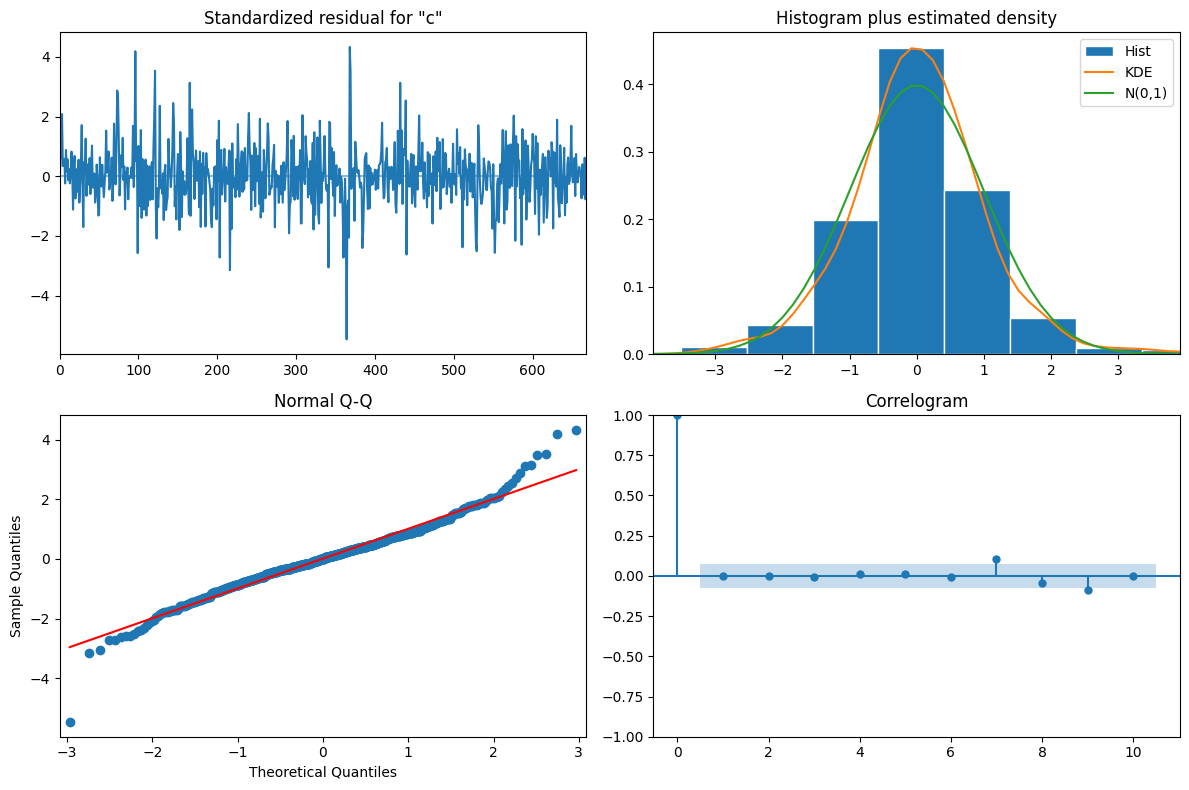

In [125]:
best_model = SARIMAX(
    y,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fit = best_model.fit(disp=False)

best_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

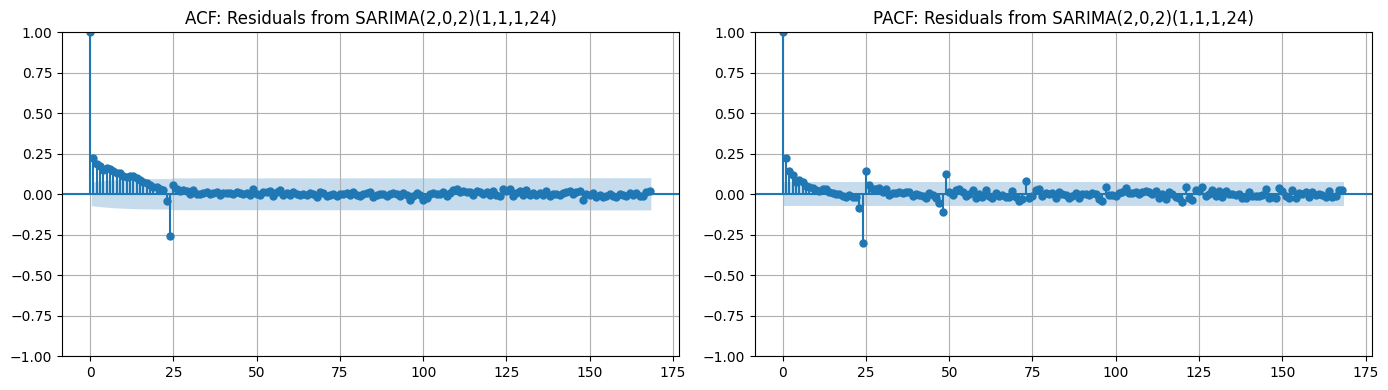

In [126]:
resid = best_fit.resid.dropna()

plot_acf_pacf(
    resid,
    "Residuals from SARIMA(2,0,2)(1,1,1,24)",
    lags=168
)

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


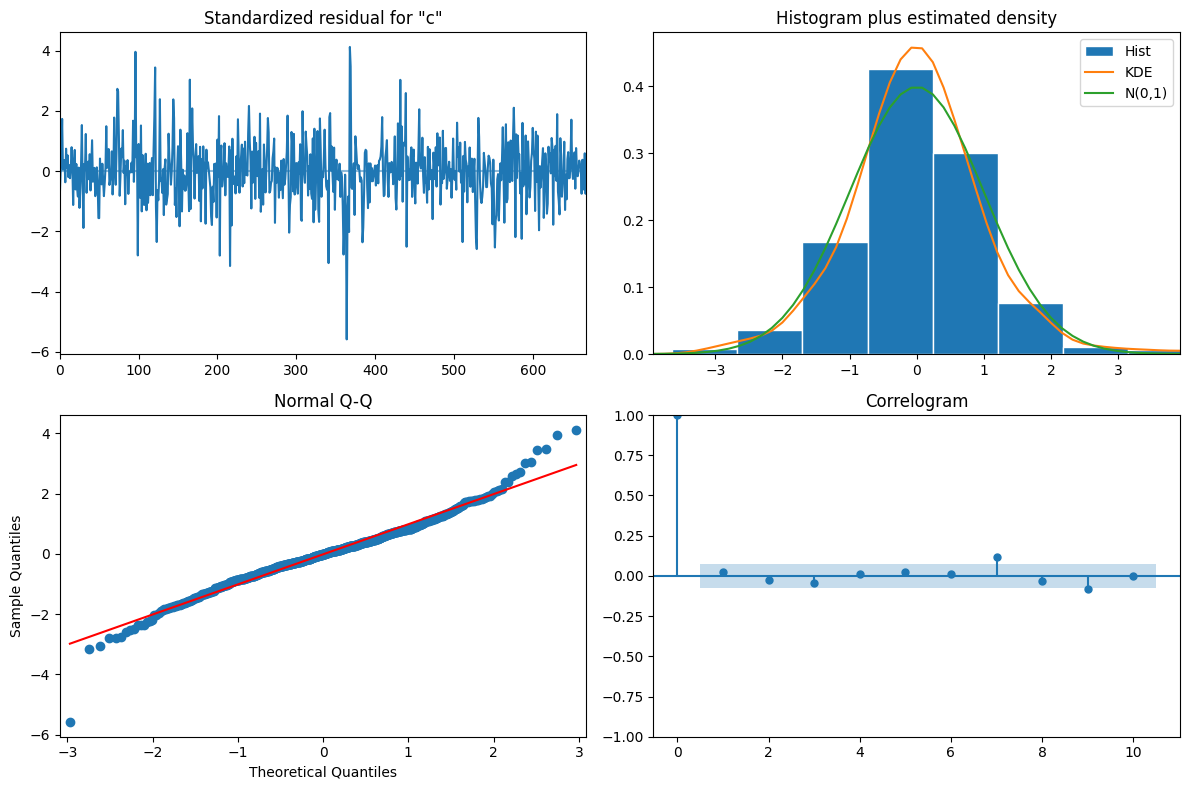

In [121]:
best_model2 = SARIMAX(
    y,
    order=(3, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fit2 = best_model2.fit(disp=False)

best_fit2.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

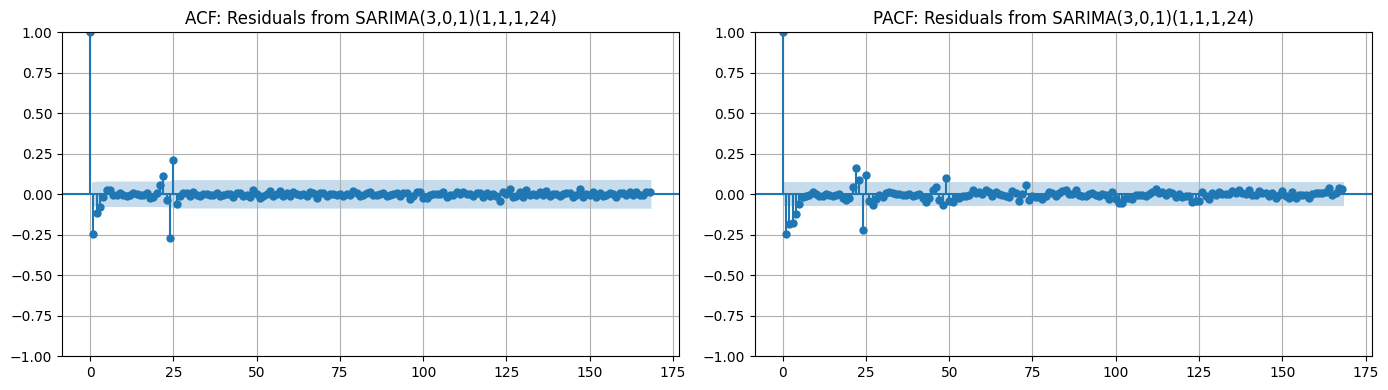

In [122]:
resid = best_fit2.resid.dropna()

plot_acf_pacf(
    resid,
    "Residuals from SARIMA(3,0,1)(1,1,1,24)",
    lags=168
)